1. Завантаження та попередня обробка даних

a. Викачати датасет Titanic із Kaggle.

b. Завантажити файл train.csv у DataFrame.

c. Вивести загальну інформацію про дані, перевірити наявність пропущених значень.

d. Заповнити пропущені значення.

e. Перетворити категоріальні ознаки у числовий формат.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print("Загальна інформація про датасет:")
df.info()

print("\nПропущені значення:")
print(df.isnull().sum())

Загальна інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Пропущені значення:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0


In [2]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


2. Поділ даних на навчальну та тестову вибірки

a. Виконати поділ даних на train/test.
    
b. Вивести розміри навчальної та тестової вибірок.

In [3]:
X = df.drop('Survived', axis=1)
y = df['Survived']

#80% -> 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Розмір навчальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

Розмір навчальної вибірки: (712, 8)
Розмір тестової вибірки: (179, 8)


3. Побудова класифікатора на основі дерев рішень

a. Навчити модель дерева рішень на навчальних даних.

b. Отримати класифікацію для тестової вибірки.

c. Проаналізувати глибину дерева та кількість вузлів.

In [4]:
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(f"Глибина побудованого дерева: {clf.get_depth()}")
print(f"Кількість листових вузлів: {clf.get_n_leaves()}")

Глибина побудованого дерева: 4
Кількість листових вузлів: 15


4. Оцінювання якості класифікації

a. Обчислити основні метрики класифікації:

    1Accuracy;
    
    2Precision;
    
    3Recall;
    
    4F1-score.
    
b. Побудувати confusion matrix.

c. Вивести детальний звіт класифікації (classification_report).

d. Проаналізувати баланс класів та пояснити, які метрики є більш інформативними для цього завдання.

Accuracy:  0.7989
Precision: 0.8393
Recall:    0.6351
F1-score:  0.7231

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       105
           1       0.84      0.64      0.72        74

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



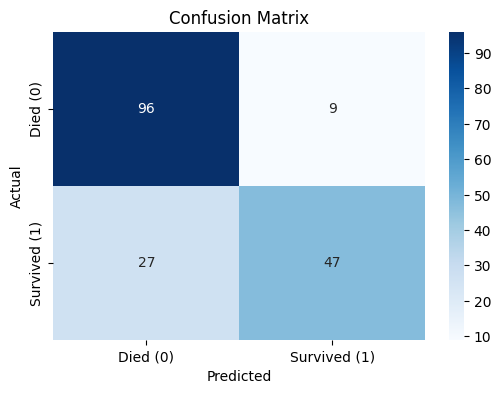

In [5]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Died (0)', 'Survived (1)'], 
            yticklabels=['Died (0)', 'Survived (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

5. Інтерпретація моделі

a. Вивести важливість ознак (feature importance), отриману з дерева рішень.

b. Проаналізувати, які характеристики пасажирів найбільше впливають на ймовірність виживання.

c. Візуалізувати дерево рішень.

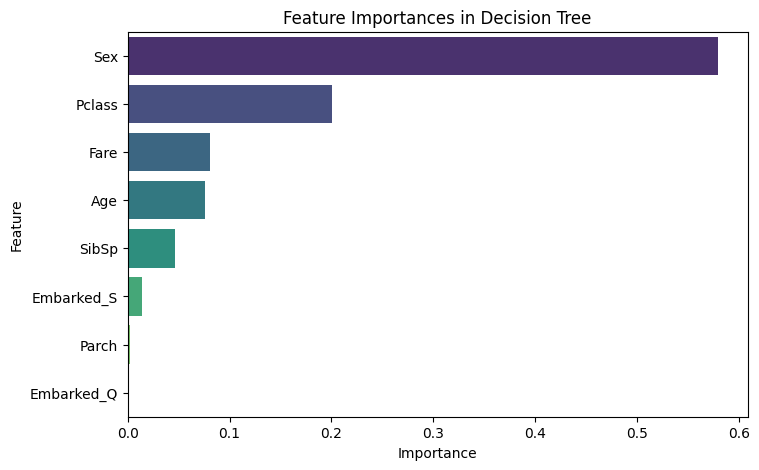

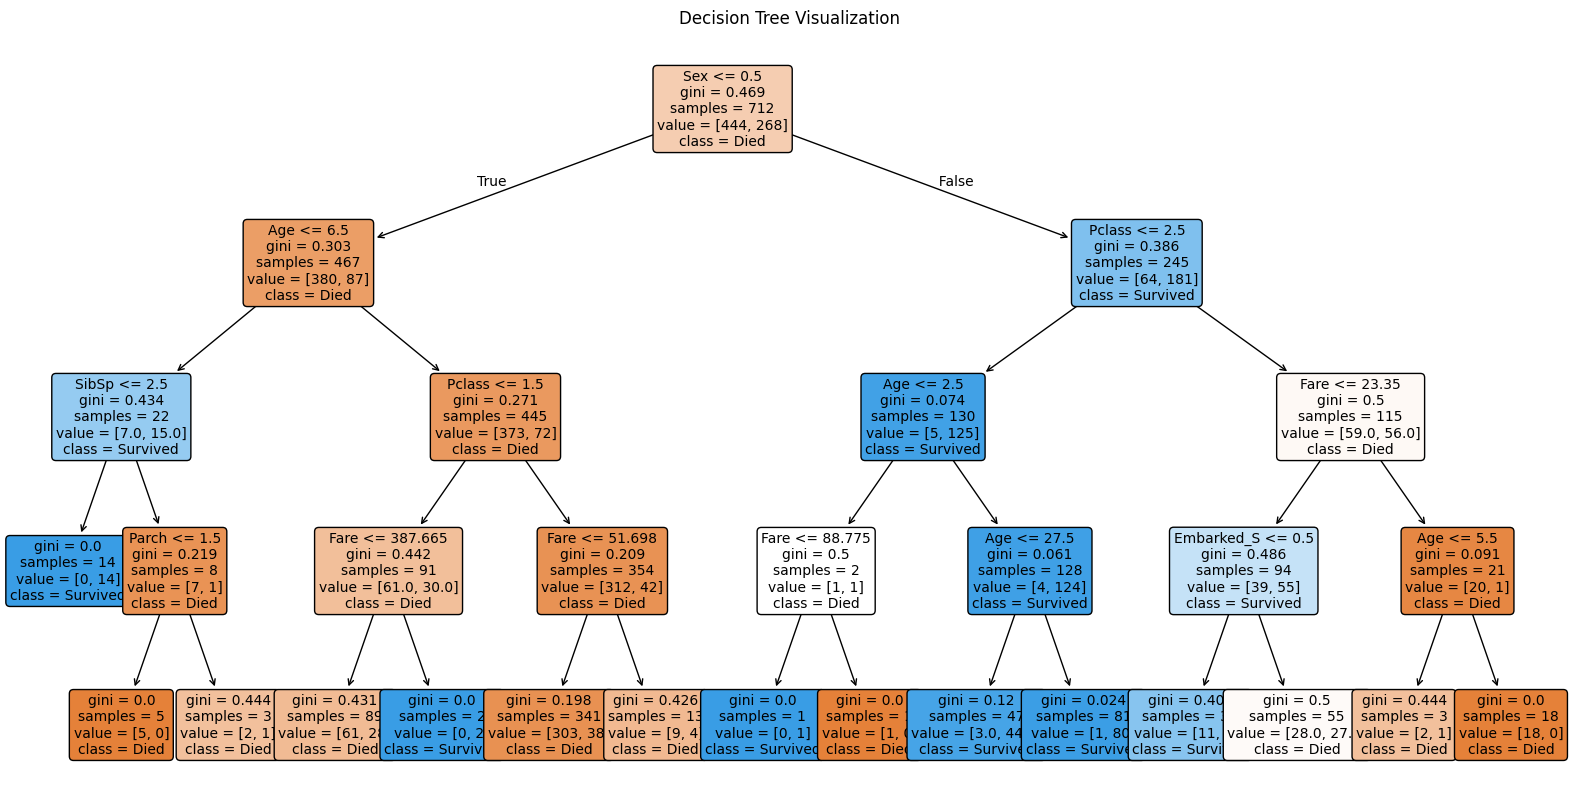

In [6]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importances, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importances in Decision Tree')
plt.show()


plt.figure(figsize=(20, 10))
plot_tree(clf, 
          feature_names=X.columns, 
          class_names=['Died', 'Survived'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title('Decision Tree Visualization')
plt.show()